In [6]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

import sys
sys.path.append("../scripts")
from vtk_reader import VTKReader

%load_ext autoreload
%autoreload 2
%matplotlib inline

In [7]:
vtk_reader = VTKReader('/home/andrey/Desktop/kiam/calculations/test_33_disturbance_none/OUTPUT/vtk')
vtk_reader.load()
phi_none = vtk_reader.phi

Detected 13 vti files
Loading done!


In [8]:
vtk_reader = VTKReader('/home/andrey/Desktop/kiam/calculations/test_33_disturbance_phi/OUTPUT/vtk')
vtk_reader.load()
phi_adapt = vtk_reader.phi

Detected 13 vti files
Loading done!


In [9]:
def norm_uniform(first, second):
    return np.abs(first - second).max(axis=(1, 2, 3))

In [10]:
norm_uniform(phi_none, phi_adapt)

array([0.00000000e+00, 2.35023105e-04, 5.75798108e-04, 1.05821576e-03,
       1.73348672e-03, 2.66504861e-03, 3.95153544e-03, 5.77611742e-03,
       8.57901120e-03, 1.42357901e-02, 3.63380836e-02, 1.60803731e-01,
       4.48273648e-01])

In [15]:
df_adapt_none = pd.read_csv('phi_mean_test_data/adaptation_none.dat', sep=' ', index_col=False)

In [17]:
df_adapt_none

,iter,model_time,time_step_prev,dphi_dt_abs_max,time_step_phi,phi_integral
0,1,1.000000e-10,1.000000e-10,3.518600e+04,0.000000e+00,4.487626e-15
1,2,2.000000e-10,1.000000e-10,3.519836e+04,2.842040e-08,4.487624e-15
2,3,3.000000e-10,1.000000e-10,3.521183e+04,2.841041e-08,4.487622e-15
3,4,4.000000e-10,1.000000e-10,3.522530e+04,2.839955e-08,4.487620e-15
4,5,5.000000e-10,1.000000e-10,3.523877e+04,2.838869e-08,4.487619e-15
...,...,...,...,...,...,...
11995,11996,1.199600e-06,1.000000e-10,2.702776e+08,1.000000e-10,3.862618e-15
11996,11997,1.199700e-06,1.000000e-10,5.221056e+08,1.000000e-10,3.862337e-15
11997,11998,1.199800e-06,1.000000e-10,1.997474e+09,1.000000e-10,3.862051e-15
11998,11999,1.199900e-06,1.000000e-10,3.469036e+08,1.000000e-10,3.861761e-15


In [19]:
df_adapt_phi = pd.read_csv('phi_mean_test_data/adaptation_phi.dat', sep=' ', index_col=False)

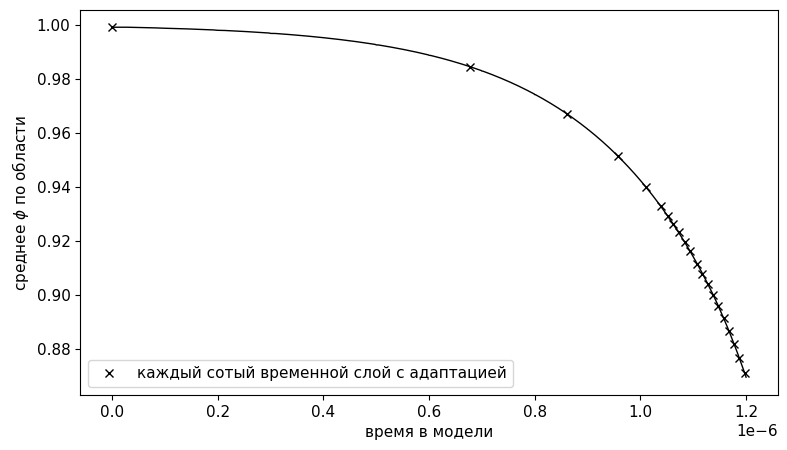

In [21]:
plt.rcParams.update({'font.size': 11})
L = 1.65e-5

plt.figure(figsize=(9, 5))#, dpi=300)
plt.xlabel('время в модели')
plt.ylabel(r'среднее $\phi$ по области')
plt.plot(df_adapt_phi['model_time'][::100], df_adapt_phi['phi_integral'][::100] / L**3, 'x', color='black')
plt.plot(df_adapt_phi['model_time'], df_adapt_phi['phi_integral'] / L**3, color='black', lw=1)
plt.legend(['каждый сотый временной слой с адаптацией'])
plt.show()

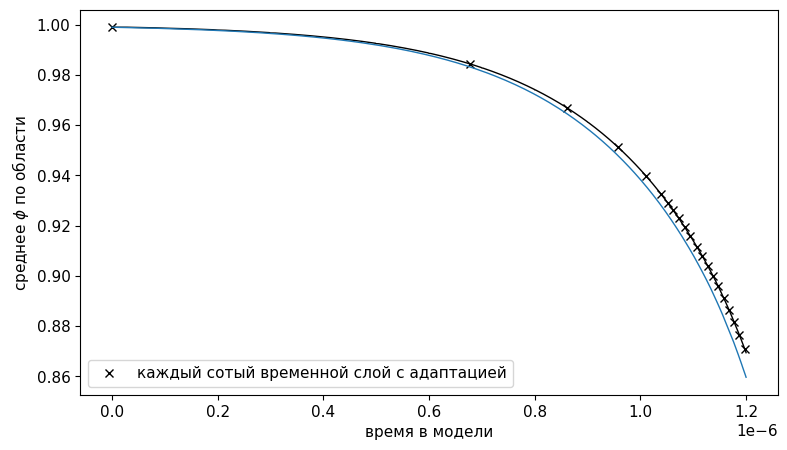

In [23]:
plt.rcParams.update({'font.size': 11})
L = 1.65e-5

plt.figure(figsize=(9, 5))
plt.xlabel('время в модели')
plt.ylabel(r'среднее $\phi$ по области')
plt.plot(df_adapt_phi['model_time'][::100], df_adapt_phi['phi_integral'][::100] / L**3, 'x', color='black')
plt.plot(df_adapt_phi['model_time'], df_adapt_phi['phi_integral'] / L**3, color='black', lw=1)
plt.plot(df_adapt_none['model_time'], df_adapt_none['phi_integral'] / L**3, color='C0', lw=1)
plt.legend(['каждый сотый временной слой с адаптацией'])
plt.show()